In [37]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json

pd.set_option('display.max_columns', None)

# IMPORTANDO DADOS

In [38]:
df_target = pd.read_csv('Target/data.csv')
df_target

,time,target_pitch,target_wy,target_tmp,target_wz,target_roll,target_ax,target_wx,target_az,target_ay,target_yaw,static
0,0.0,7.939,-4.84356,62.4,-23.82033,-7.197,1.405646,29.79857,-1.316572,9.598631,232.319,False
1,0.1,7.939,-4.84356,62.4,-23.82033,-7.197,1.405646,29.79857,-1.316572,9.598631,232.319,False
2,0.2,10.116,-4.18652,62.7,-19.93097,-4.417,1.801648,26.69136,-0.581466,9.487257,231.400,False
3,0.3,11.756,-0.70288,62.3,-13.30208,-2.055,2.068095,23.18623,-0.425383,9.490690,230.690,False
4,0.4,12.788,-0.70880,62.7,-6.32595,-0.018,2.226011,14.00286,1.362183,10.754561,230.331,False
...,...,...,...,...,...,...,...,...,...,...,...,...
28995,2899.5,-2.162,-0.20057,62.2,-0.40124,1.839,-0.351990,-0.19655,0.317176,9.806356,239.615,True
28996,2899.6,-2.160,0.15263,62.0,-0.03069,1.838,-0.379655,-0.04077,0.335123,9.805042,239.616,True
28997,2899.7,-2.161,0.15371,62.1,0.36778,1.837,-0.369642,-0.07036,0.326238,9.736317,239.616,True
28998,2899.8,-2.162,0.03562,62.2,-0.32986,1.835,-0.336741,0.33753,0.311646,9.812877,239.617,True


In [39]:
df_ref = pd.read_csv('Reference/data.csv')
df_ref

,time,ref_sample_time,ref_pitch,ref_q1,ref_q2,ref_wz,ref_q3,ref_az,ref_roll,ref_ax,ref_la_pos_mon_d,ref_wx,ref_wy,ref_q0,ref_ay,ref_yaw,static
0,0.0,505000000.0,7.098947,0.3712,-0.5229,-27.782723,-0.6765,-2.09200,79.698429,0.7386,0.23230,27.467597,-3.705891,0.3620,-9.682,-117.742827,False
1,0.1,505000000.0,7.098947,0.3712,-0.5229,-27.782723,-0.6765,-2.09200,79.698429,0.7386,0.23230,27.467597,-3.705891,0.3620,-9.682,-117.742827,False
2,0.2,605000000.0,9.637150,0.3892,-0.5312,-25.284627,-0.6735,-1.57700,82.276739,1.3800,0.23000,26.247197,-3.414256,0.3359,-9.483,-118.544968,False
3,0.3,705000000.0,11.459156,0.4032,-0.5382,-16.512644,-0.6689,-1.21900,84.396683,1.8730,0.22960,21.382785,-0.638848,0.3166,-9.313,-118.946038,False
4,0.4,805000000.0,12.679556,0.4155,-0.5455,-10.467939,-0.6618,-0.80840,86.516627,2.1420,0.23090,20.368650,2.102182,0.3029,-9.384,-118.888742,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28995,2899.5,805000000.0,-6.606203,0.1390,-0.6948,-0.031387,-0.6714,0.03985,90.240853,-0.3455,0.05073,-0.008486,-0.034813,0.2171,-9.783,-150.802492,True
28996,2899.6,905000000.0,-6.606203,0.1389,-0.6948,-0.010451,-0.6714,0.03972,90.240853,-0.3449,0.05080,0.002791,-0.032384,0.2171,-9.784,-150.802492,True
28997,2899.7,5000000.0,-6.611933,0.1389,-0.6948,0.008789,-0.6714,0.03956,90.240853,-0.3449,0.05088,-0.002540,-0.028390,0.2171,-9.783,-150.802492,True
28998,2899.8,105000000.0,-6.606203,0.1389,-0.6948,-0.000646,-0.6714,0.03989,90.240853,-0.3453,0.05095,-0.016742,-0.033346,0.2171,-9.783,-150.802492,True


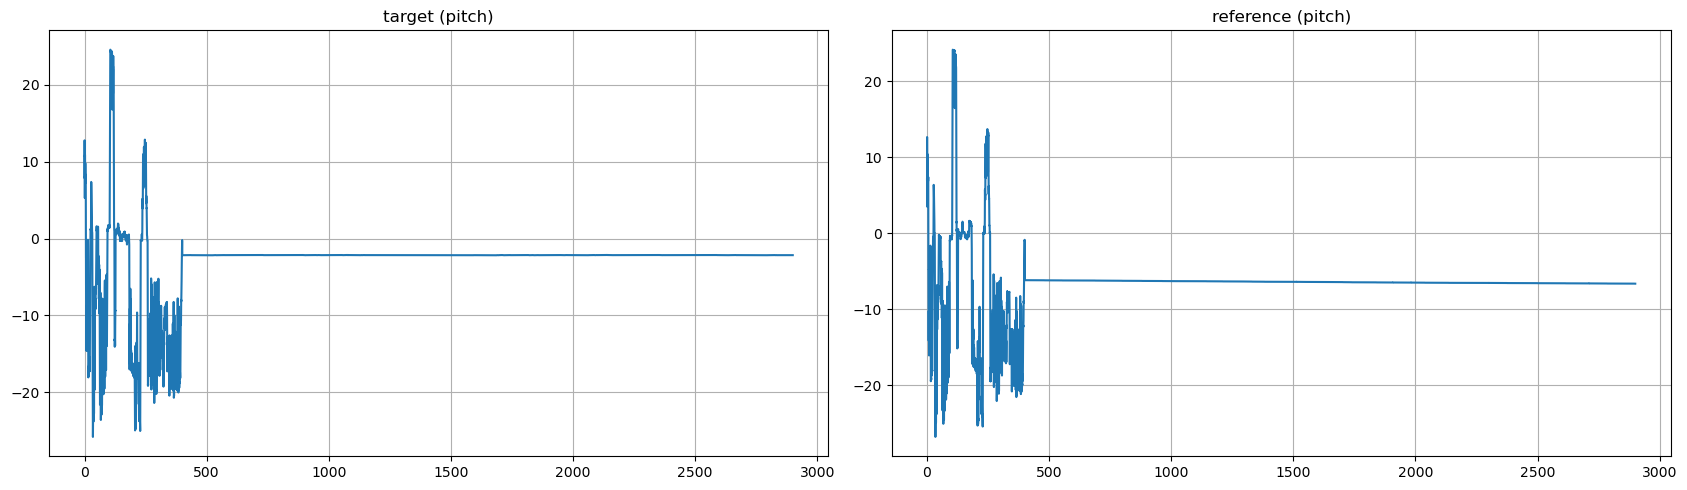

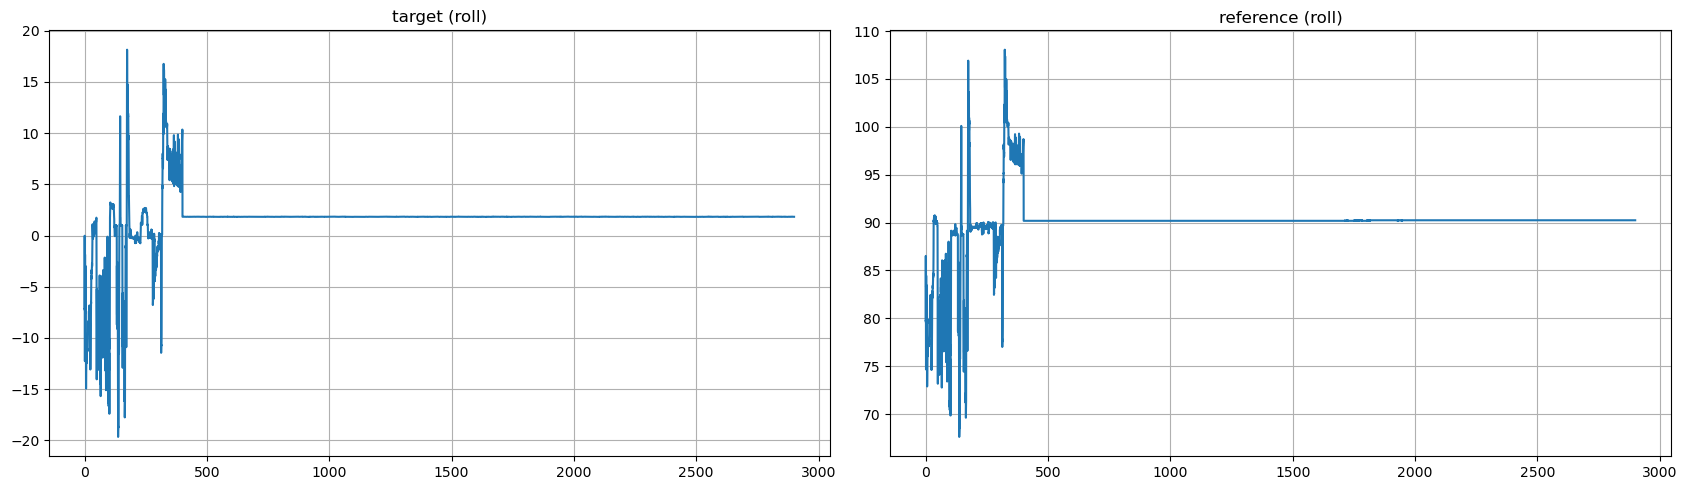

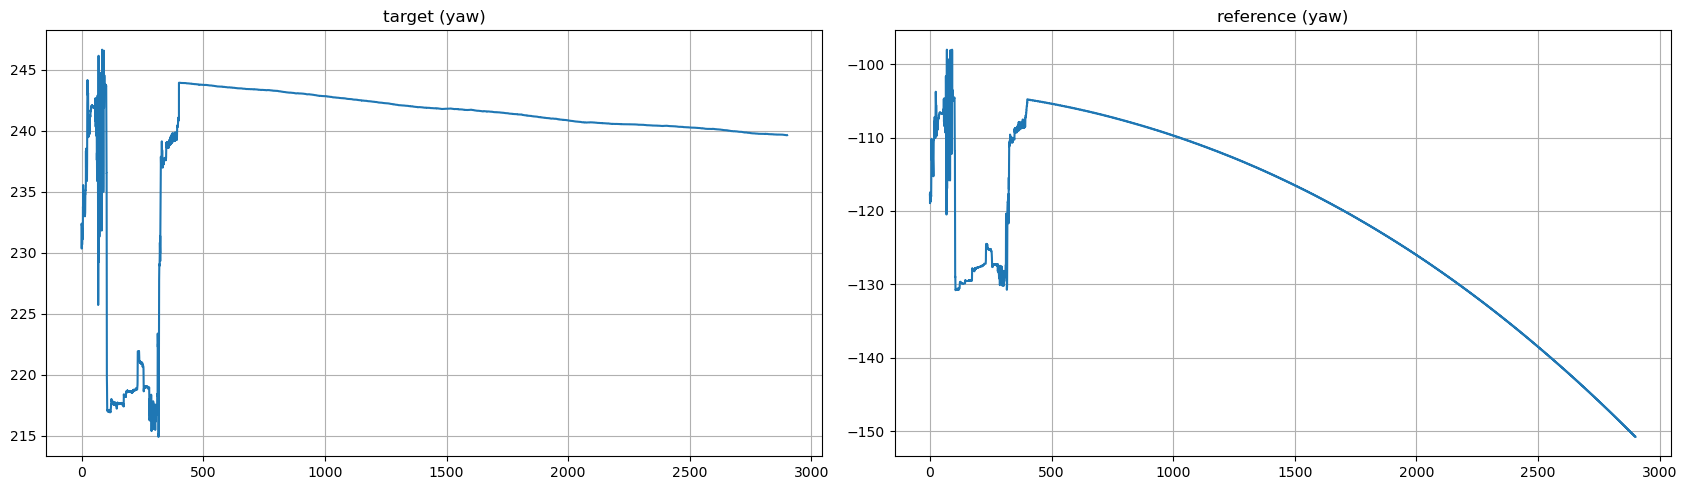

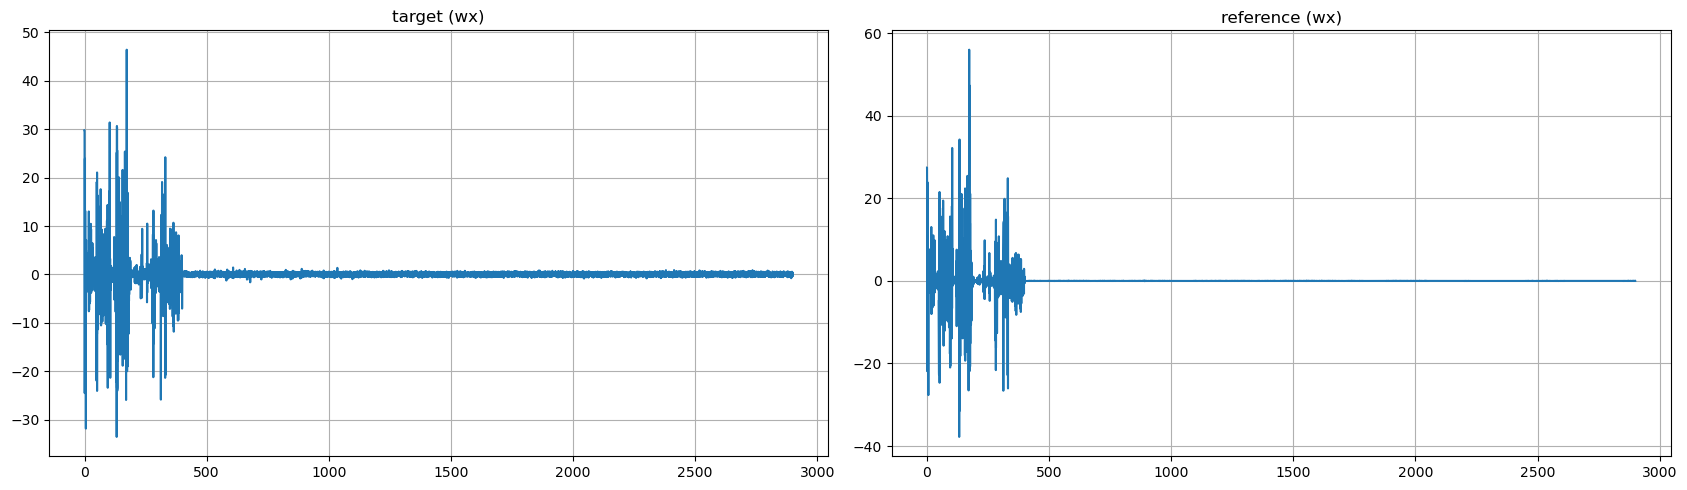

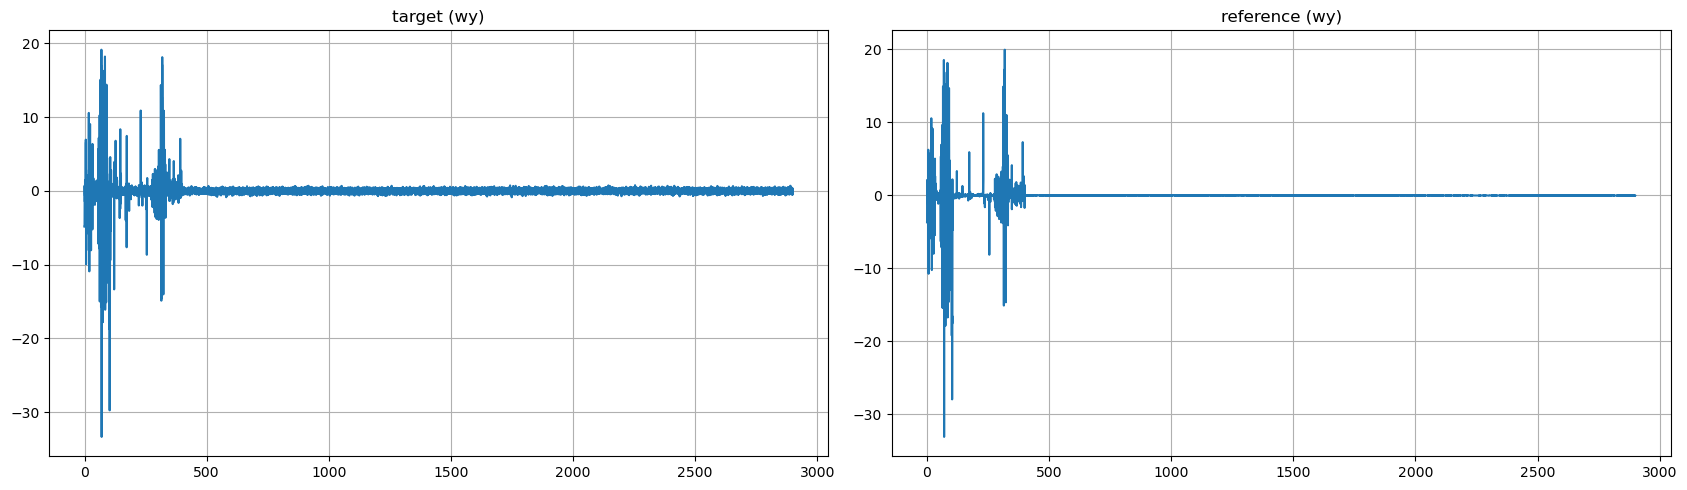

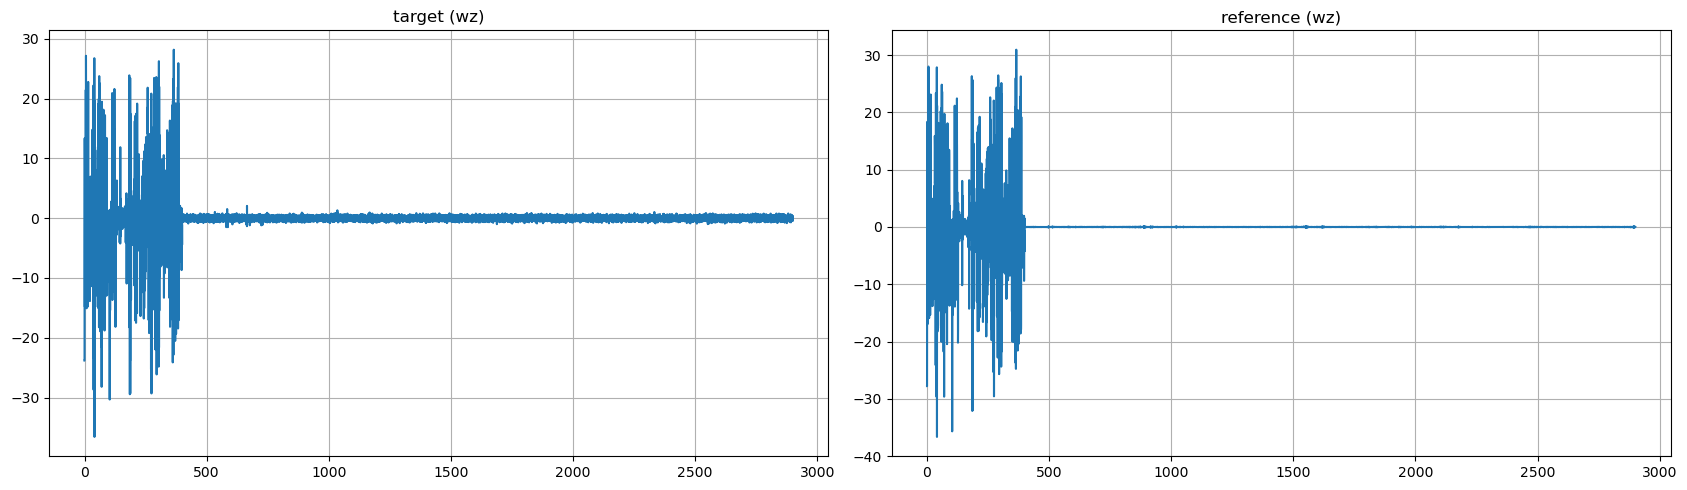

In [40]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'target ({var})':    df_target[f'target_{var}'], 
        f'reference ({var})': df_ref[f'ref_{var}']
    }, time=df_ref.time, figsize=(17, 5))

In [41]:
df = pd.merge_asof(df_target, df_ref, on='time', by='static', direction='nearest')
df

,time,target_pitch,target_wy,target_tmp,target_wz,target_roll,target_ax,target_wx,target_az,target_ay,target_yaw,static,ref_sample_time,ref_pitch,ref_q1,ref_q2,ref_wz,ref_q3,ref_az,ref_roll,ref_ax,ref_la_pos_mon_d,ref_wx,ref_wy,ref_q0,ref_ay,ref_yaw
0,0.0,7.939,-4.84356,62.4,-23.82033,-7.197,1.405646,29.79857,-1.316572,9.598631,232.319,False,505000000.0,7.098947,0.3712,-0.5229,-27.782723,-0.6765,-2.09200,79.698429,0.7386,0.23230,27.467597,-3.705891,0.3620,-9.682,-117.742827
1,0.1,7.939,-4.84356,62.4,-23.82033,-7.197,1.405646,29.79857,-1.316572,9.598631,232.319,False,505000000.0,7.098947,0.3712,-0.5229,-27.782723,-0.6765,-2.09200,79.698429,0.7386,0.23230,27.467597,-3.705891,0.3620,-9.682,-117.742827
2,0.2,10.116,-4.18652,62.7,-19.93097,-4.417,1.801648,26.69136,-0.581466,9.487257,231.400,False,605000000.0,9.637150,0.3892,-0.5312,-25.284627,-0.6735,-1.57700,82.276739,1.3800,0.23000,26.247197,-3.414256,0.3359,-9.483,-118.544968
3,0.3,11.756,-0.70288,62.3,-13.30208,-2.055,2.068095,23.18623,-0.425383,9.490690,230.690,False,705000000.0,11.459156,0.4032,-0.5382,-16.512644,-0.6689,-1.21900,84.396683,1.8730,0.22960,21.382785,-0.638848,0.3166,-9.313,-118.946038
4,0.4,12.788,-0.70880,62.7,-6.32595,-0.018,2.226011,14.00286,1.362183,10.754561,230.331,False,805000000.0,12.679556,0.4155,-0.5455,-10.467939,-0.6618,-0.80840,86.516627,2.1420,0.23090,20.368650,2.102182,0.3029,-9.384,-118.888742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28995,2899.5,-2.162,-0.20057,62.2,-0.40124,1.839,-0.351990,-0.19655,0.317176,9.806356,239.615,True,805000000.0,-6.606203,0.1390,-0.6948,-0.031387,-0.6714,0.03985,90.240853,-0.3455,0.05073,-0.008486,-0.034813,0.2171,-9.783,-150.802492
28996,2899.6,-2.160,0.15263,62.0,-0.03069,1.838,-0.379655,-0.04077,0.335123,9.805042,239.616,True,905000000.0,-6.606203,0.1389,-0.6948,-0.010451,-0.6714,0.03972,90.240853,-0.3449,0.05080,0.002791,-0.032384,0.2171,-9.784,-150.802492
28997,2899.7,-2.161,0.15371,62.1,0.36778,1.837,-0.369642,-0.07036,0.326238,9.736317,239.616,True,5000000.0,-6.611933,0.1389,-0.6948,0.008789,-0.6714,0.03956,90.240853,-0.3449,0.05088,-0.002540,-0.028390,0.2171,-9.783,-150.802492
28998,2899.8,-2.162,0.03562,62.2,-0.32986,1.835,-0.336741,0.33753,0.311646,9.812877,239.617,True,105000000.0,-6.606203,0.1389,-0.6948,-0.000646,-0.6714,0.03989,90.240853,-0.3453,0.05095,-0.016742,-0.033346,0.2171,-9.783,-150.802492


In [42]:
df.to_csv('output.csv', index=None)